In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('lol_clean_final.csv')

lanes = ['top', 'jungle', 'middle', 'bottom', 'utility']
lane_kr = {'top': '탑', 'jungle': '정글', 'middle': '미드', 'bottom': '원딜', 'utility': '서폿'}

print(f"데이터 로드 완료: {df.shape[0]}게임, {df.shape[1]}컬럼")

데이터 로드 완료: 8410게임, 80컬럼


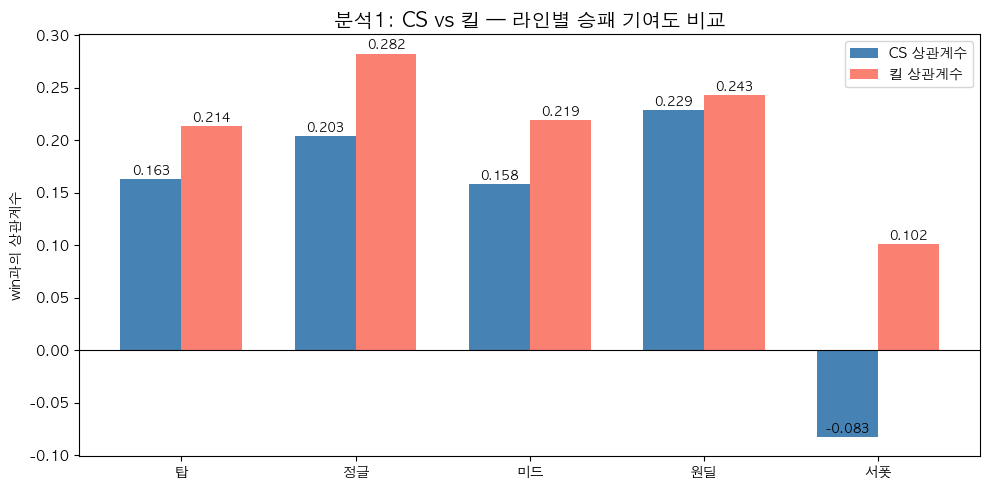

라인  CS 상관계수  킬 상관계수  킬-CS 차이
 탑   0.1626  0.2138   0.0512
정글   0.2035  0.2824   0.0790
미드   0.1580  0.2192   0.0613
원딜   0.2289  0.2433   0.0144
서폿  -0.0826  0.1015   0.1841


In [2]:
# ── 분석1: CS vs 킬 — 어떤 골드가 더 가치있나 ──────────────────────────

cs_corr   = []
kill_corr = []

for lane in lanes:
    cs_corr.append(df[f'blue_{lane}_cs'].corr(df['win']))
    kill_corr.append(df[f'blue_{lane}_kills'].corr(df['win']))

x = np.arange(len(lanes))
width = 0.35
labels = [lane_kr[l] for l in lanes]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cs_corr,   width, label='CS 상관계수',  color='steelblue')
bars2 = ax.bar(x + width/2, kill_corr, width, label='킬 상관계수', color='salmon')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('win과의 상관계수')
ax.set_title('분석1: CS vs 킬 — 라인별 승패 기여도 비교', fontsize=14)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

result1 = pd.DataFrame({
    '라인': labels,
    'CS 상관계수':   [round(v, 4) for v in cs_corr],
    '킬 상관계수':  [round(v, 4) for v in kill_corr],
    '킬-CS 차이':   [round(k - c, 4) for c, k in zip(cs_corr, kill_corr)]
})
print(result1.to_string(index=False))

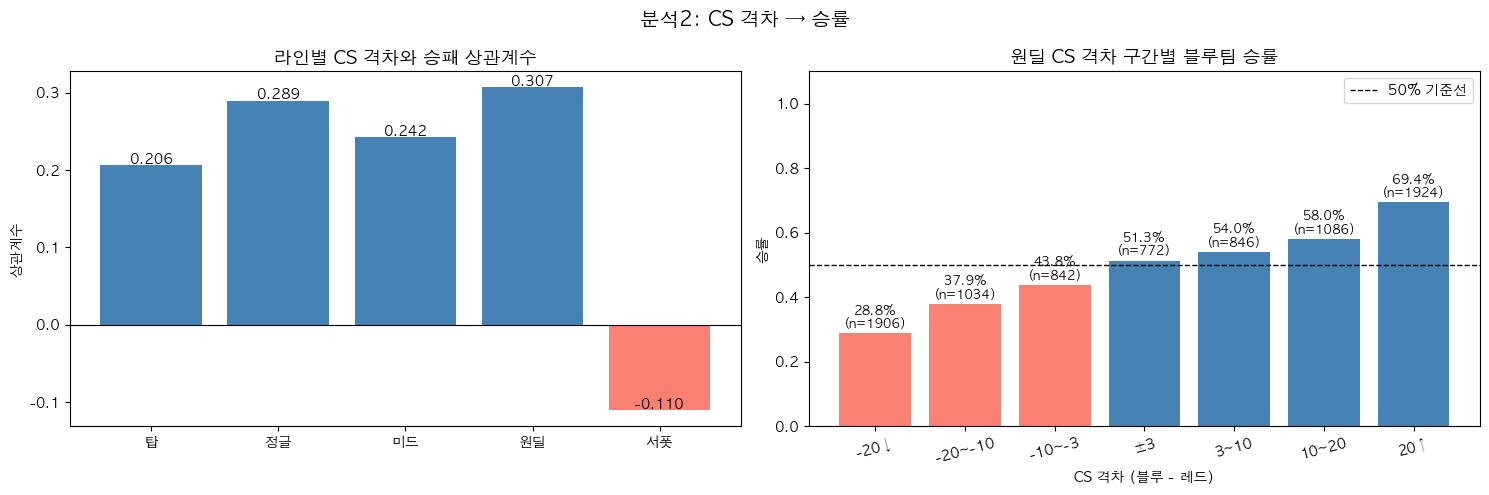

=== 라인별 CS 격차-승패 상관계수 (내림차순) ===
라인  CS격차 상관계수
원딜     0.3066
정글     0.2893
미드     0.2423
 탑     0.2062
서폿    -0.1099

=== 원딜 CS 격차 구간별 승률 ===
CS격차 구간       승률  게임수
   -20↓ 0.287513 1906
-20~-10 0.379110 1034
 -10~-3 0.438242  842
     ±3 0.512953  772
   3~10 0.540189  846
  10~20 0.580110 1086
    20↑ 0.693867 1924


In [3]:
# ── 분석2: CS 격차 → 승률 ──────────────────────────────────────────────

for lane in lanes:
    df[f'{lane}_cs_diff'] = df[f'blue_{lane}_cs'] - df[f'red_{lane}_cs']

# 2-1: 라인별 CS 격차 vs win 상관계수
cs_diff_corr = [df[f'{lane}_cs_diff'].corr(df['win']) for lane in lanes]
labels = [lane_kr[l] for l in lanes]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(labels, cs_diff_corr,
                   color=['steelblue' if v > 0 else 'salmon' for v in cs_diff_corr])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('라인별 CS 격차와 승패 상관계수', fontsize=13)
axes[0].set_ylabel('상관계수')
for bar, v in zip(bars, cs_diff_corr):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.3f}', ha='center', fontsize=10)

# 2-2: 미드 라인 CS 격차 구간별 승률 (상관계수 가장 높은 라인)
best_lane = lanes[int(np.argmax(cs_diff_corr))]
col = f'{best_lane}_cs_diff'
bins   = [-np.inf, -20, -10, -3, 3, 10, 20, np.inf]
bin_labels = ['-20↓', '-20~-10', '-10~-3', '±3', '3~10', '10~20', '20↑']
df['cs_diff_bin'] = pd.cut(df[col], bins=bins, labels=bin_labels)

wr = df.groupby('cs_diff_bin', observed=True)['win'].agg(['mean', 'count']).reset_index()
wr.columns = ['CS격차 구간', '승률', '게임수']

bars2 = axes[1].bar(wr['CS격차 구간'], wr['승률'],
                    color=['salmon' if w < 0.5 else 'steelblue' for w in wr['승률']])
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% 기준선')
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f'{lane_kr[best_lane]} CS 격차 구간별 블루팀 승률', fontsize=13)
axes[1].set_xlabel('CS 격차 (블루 - 레드)')
axes[1].set_ylabel('승률')
axes[1].legend()
plt.xticks(rotation=15)
for bar, rate, cnt in zip(bars2, wr['승률'], wr['게임수']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={cnt})', ha='center', va='bottom', fontsize=9)

plt.suptitle('분석2: CS 격차 → 승률', fontsize=14)
plt.tight_layout()
plt.show()

print(f"=== 라인별 CS 격차-승패 상관계수 (내림차순) ===")
result2 = pd.DataFrame({'라인': labels, 'CS격차 상관계수': [round(v,4) for v in cs_diff_corr]})
print(result2.sort_values('CS격차 상관계수', ascending=False).to_string(index=False))
print(f"\n=== {lane_kr[best_lane]} CS 격차 구간별 승률 ===")
print(wr.to_string(index=False))

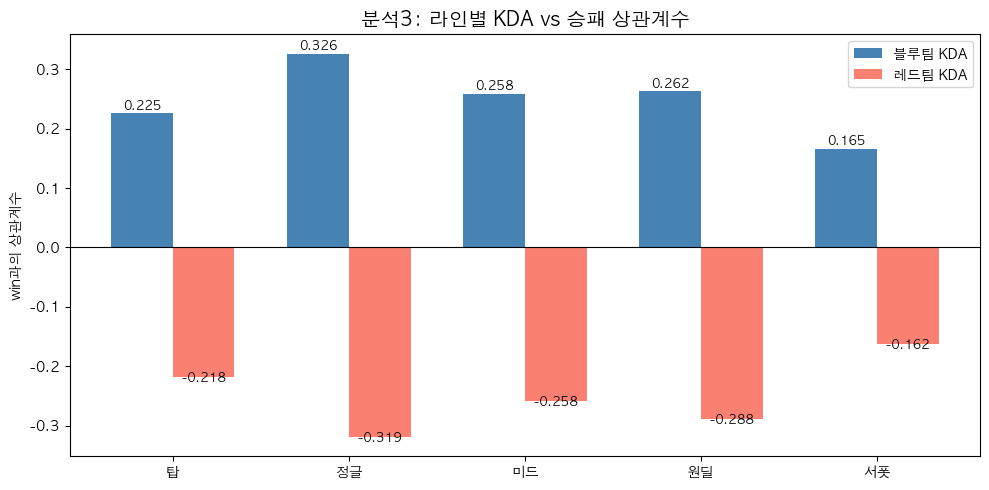

라인  블루 KDA 상관계수  레드 KDA 상관계수
정글       0.3260      -0.3187
원딜       0.2625      -0.2878
미드       0.2585      -0.2581
 탑       0.2253      -0.2180
서폿       0.1653      -0.1617


In [4]:
# ── 분석3: 라인별 KDA 효율 ─────────────────────────────────────────────

for lane in lanes:
    df[f'blue_{lane}_kda'] = df[f'blue_{lane}_kills'] / (df[f'blue_{lane}_deaths'] + 1)
    df[f'red_{lane}_kda']  = df[f'red_{lane}_kills']  / (df[f'red_{lane}_deaths']  + 1)

blue_kda_corr = [df[f'blue_{lane}_kda'].corr(df['win']) for lane in lanes]
red_kda_corr  = [df[f'red_{lane}_kda'].corr(df['win'])  for lane in lanes]
labels = [lane_kr[l] for l in lanes]

x = np.arange(len(lanes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, blue_kda_corr, width, label='블루팀 KDA', color='steelblue')
bars2 = ax.bar(x + width/2, red_kda_corr,  width, label='레드팀 KDA', color='salmon')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.003 if bar.get_height() >= 0 else -0.012),
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.003 if bar.get_height() >= 0 else -0.012),
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('win과의 상관계수')
ax.set_title('분석3: 라인별 KDA vs 승패 상관계수', fontsize=14)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

result3 = pd.DataFrame({
    '라인': labels,
    '블루 KDA 상관계수': [round(v, 4) for v in blue_kda_corr],
    '레드 KDA 상관계수': [round(v, 4) for v in red_kda_corr],
})
print(result3.sort_values('블루 KDA 상관계수', ascending=False).to_string(index=False))

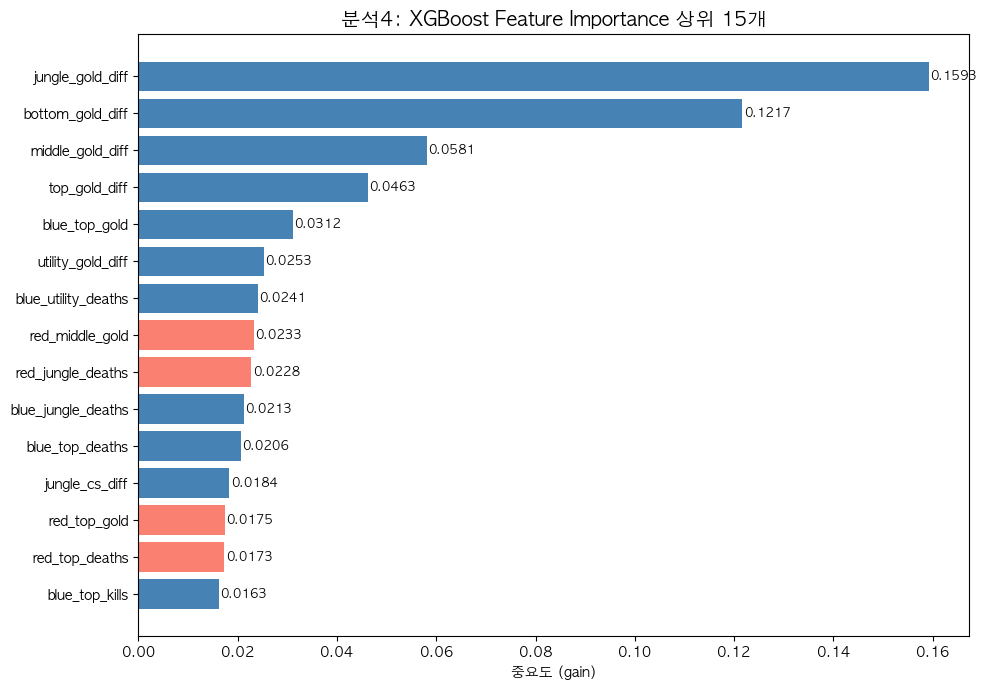

=== Feature Importance 상위 15개 ===
                 피처      중요도
   jungle_gold_diff 0.159280
   bottom_gold_diff 0.121681
   middle_gold_diff 0.058145
      top_gold_diff 0.046269
      blue_top_gold 0.031172
  utility_gold_diff 0.025309
blue_utility_deaths 0.024109
    red_middle_gold 0.023315
  red_jungle_deaths 0.022755
 blue_jungle_deaths 0.021259
    blue_top_deaths 0.020625
     jungle_cs_diff 0.018355
       red_top_gold 0.017454
     red_top_deaths 0.017337
     blue_top_kills 0.016250


In [5]:
# ── 분석4: 라인별 피처 중요도 종합 (XGBoost Feature Importance) ─────────

feature_cols = []
for lane in lanes:
    for team in ['blue', 'red']:
        feature_cols += [
            f'{team}_{lane}_gold',
            f'{team}_{lane}_cs',
            f'{team}_{lane}_kills',
            f'{team}_{lane}_deaths',
        ]
    feature_cols.append(f'{lane}_gold_diff')
    feature_cols.append(f'{lane}_cs_diff')

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['win']

model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model.fit(X, y)

importance_df = pd.DataFrame({
    '피처': feature_cols,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if 'blue' in f or 'diff' in f else 'salmon'
          for f in importance_df['피처']]
ax.barh(importance_df['피처'][::-1], importance_df['중요도'][::-1], color=colors[::-1])
ax.set_title('분석4: XGBoost Feature Importance 상위 15개', fontsize=14)
ax.set_xlabel('중요도 (gain)')
for i, (v, name) in enumerate(zip(importance_df['중요도'][::-1], importance_df['피처'][::-1])):
    ax.text(v + 0.0003, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("=== Feature Importance 상위 15개 ===")
print(importance_df.to_string(index=False))